<a href="https://colab.research.google.com/github/arpita0911/SentimentAnalysis_CollegeReviews/blob/main/SentimentAnalysis_CollegeReviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing files

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving collegereview2021.csv to collegereview2021 (2).csv
Saving collegereview2022.csv to collegereview2022 (2).csv
Saving collegereview2023.csv to collegereview2023 (2).csv


In [ ]:
import pandas as pd
import io

dfs = {}

for file_name in uploaded.keys():
    try:
        df = pd.read_csv(file_name, encoding="utf-8", on_bad_lines="skip")
        dfs[file_name] = df
        print(f"Successfully loaded {file_name}")
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

Successfully loaded collegereview2021 (2).csv
Successfully loaded collegereview2022 (2).csv
Error reading collegereview2023 (2).csv: Error tokenizing data. C error: Buffer overflow caught - possible malformed input file.



In [ ]:
with open("collegereview2023.csv", "r", encoding="utf-8", errors="ignore") as f:
    for i in range(5):
        print(f.readline())

,Name,college,review,rating

0,Aariz Amaan,IILM University,The faculty-student ratio is good none of the students go unnoticed if they participate well. Faculties are highly experienced and hold Ph.D. in their respective fields. Mid-sem and end-sem exams are not that tough if you have studied well before the exams.The campus is lush green and spacious classes are well equipped with Ac and labs are good too. Hostels are newly made. You can avail of all books from the library itself. Sports facilities are good too. There is a Haldiram outlet within the campus.,7.0

1,Saurabh,Lovely Professional University - [LPU],"There are many fests. In which the name of the annual fest is lpu fest that all are conducted in the month of December and January

There is availability of all the books in the library that a student want.

There are amenities in Every classroom.



In [ ]:
try:
    df_2023 = pd.read_csv("collegereview2023.csv", engine="python", encoding="utf-8", on_bad_lines="skip", quoting=3)
    print("Successfully loaded collegereview2023.csv")
except Exception as e:
    print(f"Error: {e}")

Successfully loaded collegereview2023.csv


In [ ]:
dfs["collegereview2023.csv"] = df_2023
df = pd.concat(dfs.values(), ignore_index=True)
print(df.head())

  Unnamed: 0               Name  \
0          0           Nimalraj   
1          1  Priyaranjan kumar   
2          2       Aftab Shaikh   
3          3        Shreya sneh   
4          4      Yuv Raj Singh   

                                             college  \
0                SNS College of Technology - [SNSCT]   
1           Bhagalpur College of Engineering - [BCE]   
2  Shree LR Tiwari College of Engineering - [SLRTCE]   
3                                    IILM University   
4                        Galgotias University - [GU]   

                                              review rating  
0  The annual fee for the course is 1,25,000. Now...    6.0  
1  The hostel life and social life in this colleg...    9.7  
2  I chose this course because I was interested i...    8.0  
3  There is IGNITE fest in the university held on...   10.0  
4  The civil department is very good in this coll...    6.2  


## EDA

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31579 entries, 0 to 31578
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  31579 non-null  object
 1   Name        30111 non-null  object
 2   college     29497 non-null  object
 3   review      29306 non-null  object
 4   rating      28816 non-null  object
dtypes: object(5)
memory usage: 1.2+ MB


,0
Unnamed: 0,0
Name,1468
college,2082
review,2273
rating,2763


In [ ]:
df.drop(columns=["Unnamed: 0", "Name"], inplace=True)

In [ ]:
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["review"] = df["review"].astype(str)

print(df.head())
print(df.dtypes)

print("Number of colleges:")
df['college'].nunique()

                                             college  \
0                SNS College of Technology - [SNSCT]   
1           Bhagalpur College of Engineering - [BCE]   
2  Shree LR Tiwari College of Engineering - [SLRTCE]   
3                                    IILM University   
4                        Galgotias University - [GU]   

                                              review  rating  
0  The annual fee for the course is 1,25,000. Now...     6.0  
1  The hostel life and social life in this colleg...     9.7  
2  I chose this course because I was interested i...     8.0  
3  There is IGNITE fest in the university held on...    10.0  
4  The civil department is very good in this coll...     6.2  
college     object
review      object
rating     float64
dtype: object
Number of colleges:


3103

Handling Missing Values

In [ ]:
print(df.isnull().sum())

college    2082
review        0
rating     2884
dtype: int64


In [ ]:
df["college"].fillna("Unknown College", inplace=True)
df["rating"].fillna(df["rating"].median(), inplace=True)

<ipython-input-12-b88ee566c191>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["college"].fillna("Unknown College", inplace=True)
<ipython-input-12-b88ee566c191>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [ ]:
print(df.isnull().sum())

college    0
review     0
rating     0
dtype: int64


Visualization

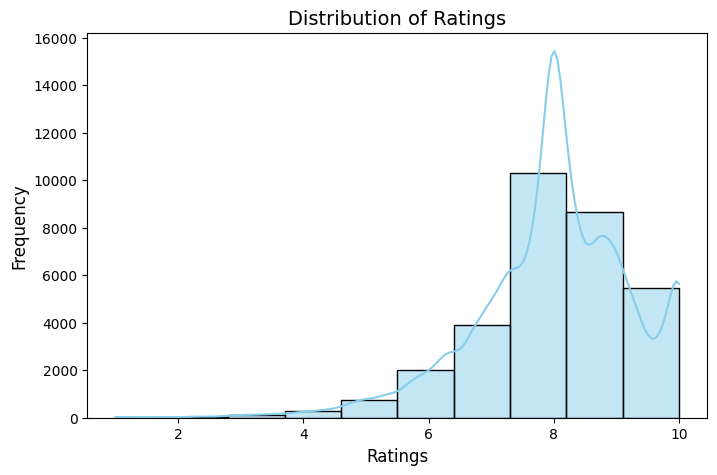

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df["rating"], bins=10, kde=True, color="skyblue")
plt.title("Distribution of Ratings", fontsize=14)
plt.xlabel("Ratings", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

# Preprocessing

In [ ]:
df['rating'] = pd.cut(df['rating'], bins=[0, 3, 7, 10], labels=[-1,0,1])

In [ ]:
df['rating'].value_counts()

,count
rating,
1,25246
0,6220
-1,113


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def clean_review(text):

    text = text.lower() #lowercase
    text = re.sub(r"\[.*?\]", "", text)  #remove bracket text
    text = re.sub(r"[^\w\s]", "", text)  #remove punctuation
    text = re.sub(r"\d+", "", text)  #remove numbers
    text = re.sub(r"\s+", " ", text).strip()  #remove extra spaces

    words = text.split()
    filtered_words = [stemmer.stem(word) for word in words if word not in stop_words] #remove stopwords and stemming

    return " ".join(filtered_words)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df["cleaned_review"] = df["review"].apply(clean_review)

print(df[["review", "cleaned_review"]].head())

                                              review  \
0  The annual fee for the course is 1,25,000. Now...   
1  The hostel life and social life in this colleg...   
2  I chose this course because I was interested i...   
3  There is IGNITE fest in the university held on...   
4  The civil department is very good in this coll...   

                                      cleaned_review  
0  annual fee cours forc pay fee earli total amou...  
1  hostel life social life colleg enjoy almost cl...  
2  chose cours interest mechan engin interest mac...  
3  ignit fest univers held campu avail journal bo...  
4  civil depart good colleg faculti member well g...  


# TF IDF Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=5000) #unigram + bigrams
tfidf_matrix = tfidf.fit_transform(df["cleaned_review"])

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
df["tfidf_score"] = tfidf_df.mean(axis=1)
print(df.head())

                                             college  \
0                SNS College of Technology - [SNSCT]   
1           Bhagalpur College of Engineering - [BCE]   
2  Shree LR Tiwari College of Engineering - [SLRTCE]   
3                                    IILM University   
4                        Galgotias University - [GU]   

                                              review rating  \
0  The annual fee for the course is 1,25,000. Now...      0   
1  The hostel life and social life in this colleg...      1   
2  I chose this course because I was interested i...      1   
3  There is IGNITE fest in the university held on...      1   
4  The civil department is very good in this coll...      0   

                                      cleaned_review  tfidf_score  
0  annual fee cours forc pay fee earli total amou...     0.001390  
1  hostel life social life colleg enjoy almost cl...     0.001428  
2  chose cours interest mechan engin interest mac...     0.001529  
3  ignit fes

# Model Training (Logistic Regression)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


X = tfidf_df  # Feature: TF-IDF matrix
y = df["rating"]  # Target: Sentiment labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=500)

model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=500, multi_class='multinomial')

# Model Evaluation

Accuracy: 0.81

Classification Report:
               precision    recall  f1-score   support

          -1       0.00      0.00      0.00        23
           0       0.62      0.18      0.28      1244
           1       0.83      0.97      0.89      5049

    accuracy                           0.81      6316
   macro avg       0.48      0.38      0.39      6316
weighted avg       0.78      0.81      0.77      6316



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


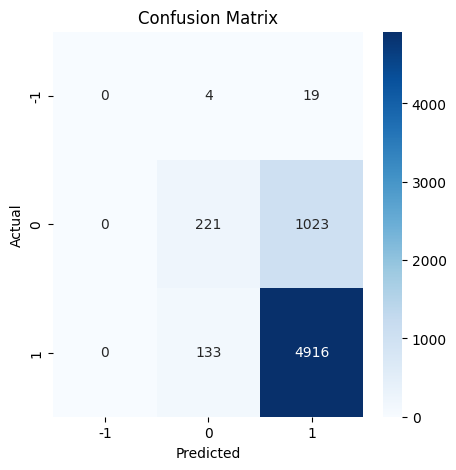

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=[-1, 0, 1], yticklabels=[-1, 0, 1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


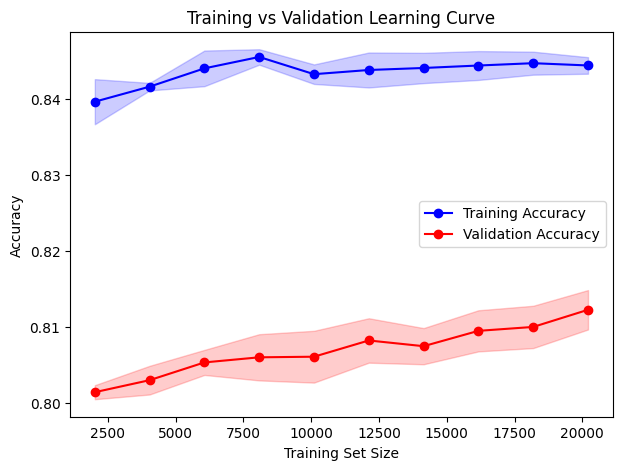

In [ ]:
import numpy as np
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train, cv=5, scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, "o-", color="blue", label="Training Accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)
plt.plot(train_sizes, val_mean, "o-", color="red", label="Validation Accuracy")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color="red", alpha=0.2)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Learning Curve")
plt.legend()
plt.show()

# SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

X = tfidf_matrix
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_smote.value_counts())


Before SMOTE:
 rating
 1    20197
 0     4976
-1       90
Name: count, dtype: int64
After SMOTE:
 rating
-1    20197
 0    20197
 1    20197
Name: count, dtype: int64


In [ ]:
model_smote = LogisticRegression(solver="lbfgs", max_iter=500, random_state=42)

model_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=500, random_state=42)

Accuracy: 0.72

Classification Report:
               precision    recall  f1-score   support

          -1       0.26      0.22      0.24        23
           0       0.37      0.59      0.45      1244
           1       0.88      0.76      0.81      5049

    accuracy                           0.72      6316
   macro avg       0.50      0.52      0.50      6316
weighted avg       0.78      0.72      0.74      6316



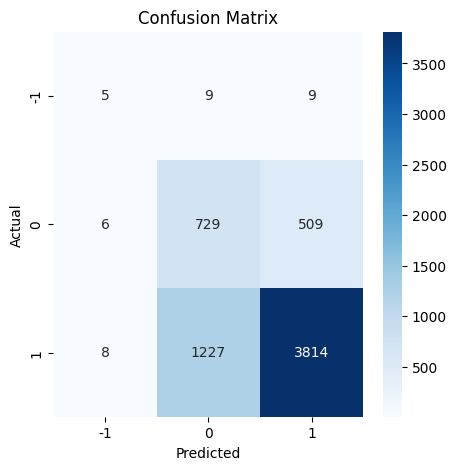

In [ ]:
y_pred = model_smote.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=[-1, 0, 1], yticklabels=[-1, 0, 1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
2 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueE

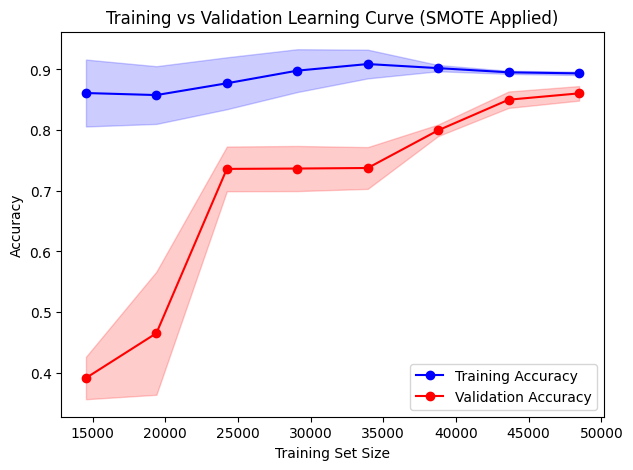

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_smote, y_train_smote, cv=5, scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, "o-", color="blue", label="Training Accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)
plt.plot(train_sizes, val_mean, "o-", color="red", label="Validation Accuracy")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color="red", alpha=0.2)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Learning Curve (SMOTE Applied)")
plt.legend()
plt.show()


# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga']
}

log_reg = LogisticRegression(random_state=42)

grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_smote, y_train_smote)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

best_model = grid_search.best_estimator_
best_model.fit(X_train_smote, y_train_smote)

y_pred = best_model.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best Hyperparameters: {'C': 10, 'solver': 'saga'}
Best Accuracy: 0.8781340636422212

Test Accuracy: 0.7272007599746675

Classification Report:
               precision    recall  f1-score   support

          -1       0.56      0.22      0.31        23
           0       0.37      0.55      0.45      1244
           1       0.87      0.77      0.82      5049

    accuracy                           0.73      6316
   macro avg       0.60      0.51      0.53      6316
weighted avg       0.77      0.73      0.74      6316



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
review_counts = df['college'].value_counts()
pd.set_option("display.max_rows", None)
print(review_counts)

college
Unknown College                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 